<a href="https://colab.research.google.com/drive/1tElT3FhddabqCyJKFH27rhnyXJTqrzke?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preprocessing

In [ ]:
import pandas as pd
import numpy as np

Press [here](https://drive.google.com/file/d/1Z39LNnF4lOj4iT48YDYFZNPDBglMd0TZ/view?usp=sharing) to download the dataset.

In [ ]:
!find . -name "forest_dataset.csv"

./forest_dataset.csv


In [ ]:
all_data = pd.read_csv('forest_dataset.csv')
all_data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
all_data.shape

(10000, 55)

In [ ]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression(C=1)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(test_labels, y_pred)

0.6075

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
clf = LogisticRegression(solver='saga')

# init GridSearchCV with parameters
param_grid = {
    'C': np.arange(1, 5),
    'penalty': ['l1', 'l2'],
}

search = GridSearchCV(clf, param_grid, n_jobs=-1, cv=5, refit=True, scoring='accuracy')

search.fit(feature_matrix, labels)

print(search.best_params_)

{'C': np.int64(1), 'penalty': 'l2'}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
accuracy_score(labels, search.best_estimator_.predict(feature_matrix))

0.6417

In the tasks, you will need to repeat this for the k Nearest Neighbors method.

# Homework

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier()

clf.fit(train_feature_matrix, train_labels)

y_pred_knn = clf.predict(test_feature_matrix)

accuracy_score(test_labels, y_pred_knn)

0.7365

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf = KNeighborsClassifier()

clf_grid = GridSearchCV(
    clf,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

clf_grid.fit(train_feature_matrix, train_labels)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['manhattan', 'euclidean'],
                         'n_neighbors': range(1, 11),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}

In [ ]:
best_knn = clf_grid.best_estimator_

y_pred_best_knn = best_knn.predict(test_feature_matrix)

accuracy_score(test_labels, y_pred_best_knn)

0.7845

In [ ]:
optimal_clf = clf_grid.best_estimator_

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

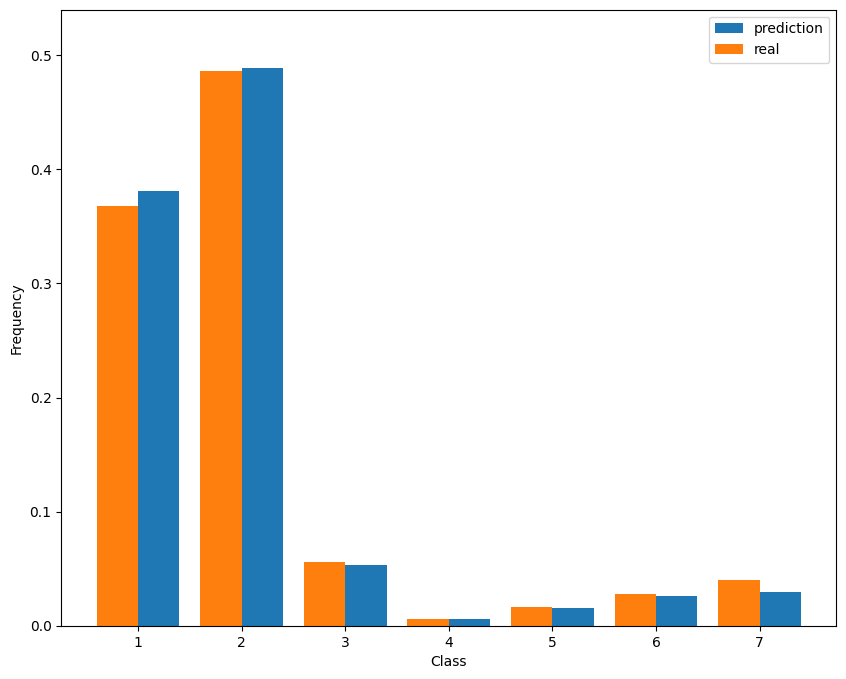

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align='edge', label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align='edge', label='real')
plt.ylim(0, 0.54)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
logreg_accuracy = 0.6075

knn_accuracy = accuracy_score(test_labels, y_pred_best_knn)

print("Logistic regression accuracy:", logreg_accuracy)
print("KNN accuracy:", knn_accuracy)

Logistic regression accuracy: 0.6075
KNN accuracy: 0.7845


In [ ]:
from sklearn.metrics import roc_auc_score

auc_roc = roc_auc_score(
    test_labels,
    pred_prob,
    multi_class='ovr',
    average='macro'
)

auc_roc

np.float64(0.9063452430548241)

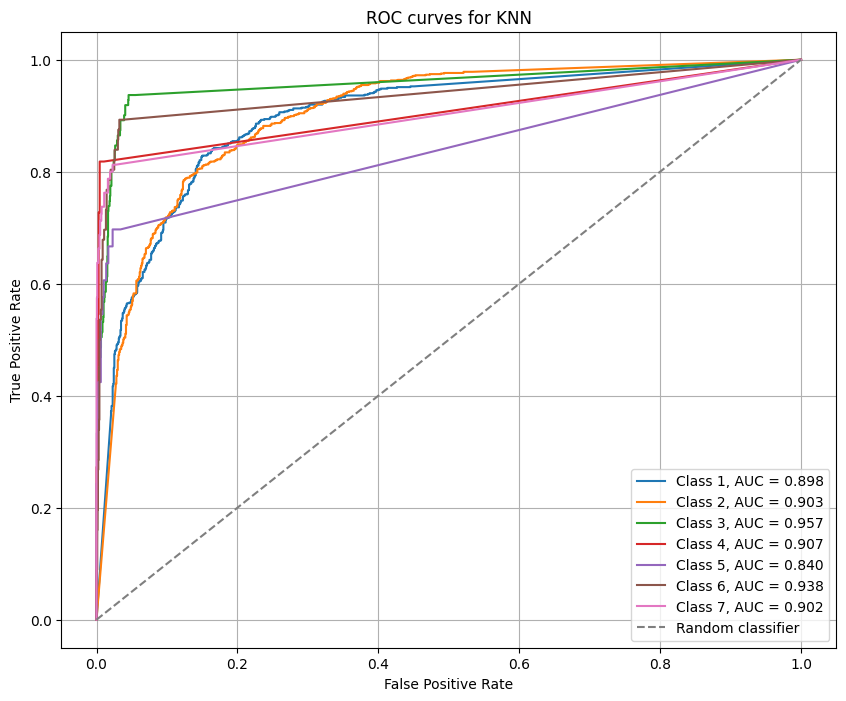

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = optimal_clf.classes_

test_labels_bin = label_binarize(test_labels, classes=classes)

plt.figure(figsize=(10, 8))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls}, AUC = {roc_auc:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for KNN')
plt.legend()
plt.grid()
plt.show()